2026-01-24 05:03:41.764188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769231021.952469      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769231022.009683      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769231022.479888      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769231022.479934      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769231022.479937      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
BRAIN TUMOR CLASSIFICATION USING ROBUST STACKED ENSEMBLE

[STEP 1] DATA LOADING AND EXPLORATION
--------------------------------------------------------------------------------
Image Size: 224x224
Batch Size: 32
Number of Classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

[STEP 2] DATA PREPROCESSING & AUGMENTATION
--------------------------------------------------------------------------------
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Training samples: 4571
Validation samples: 1141
Testing samples: 1311

[STEP 3] BUILDING TRANSFER LEARNING MODELS
--------------------------------------------------------------------------------

Building ResNet50 model...


I0000 00:00:1769231037.349966      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769231037.353787      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ ResNet50 created successfully. Trainable params: 1186564

Building EfficientNetB3 model...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ EfficientNetB3 created successfully. Trainable params: 923396

Building DenseNet121 model...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ DenseNet121 created successfully. Trainable params: 660228

Building InceptionV3 model...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ InceptionV3 created successfully. Trainable params: 1186564

[STEP 4] TRAINING MODELS
--------------------------------------------------------------------------------

[PHASE 1] Feature Extraction (Frozen Base)

Training ResNet50...
Epoch 1/30


I0000 00:00:1769231056.800850     130 service.cc:152] XLA service 0x7f3a68003f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769231056.800889     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769231056.800895     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769231058.867577     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/143 ━━━━━━━━━━━━━━━━━━━━ 42:36 18s/step - accuracy: 0.1250 - loss: 2.5118 - precision: 0.1304 - recall: 0.0938

I0000 00:00:1769231066.253880     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


143/143 ━━━━━━━━━━━━━━━━━━━━ 106s 622ms/step - accuracy: 0.4907 - loss: 1.3507 - precision: 0.5343 - recall: 0.4274 - val_accuracy: 0.7134 - val_loss: 0.8178 - val_precision: 0.7810 - val_recall: 0.6407 - learning_rate: 1.0000e-04
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 52s 364ms/step - accuracy: 0.8032 - loss: 0.5480 - precision: 0.8313 - recall: 0.7664 - val_accuracy: 0.7581 - val_loss: 0.7115 - val_precision: 0.7935 - val_recall: 0.7274 - learning_rate: 1.0000e-04
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 52s 366ms/step - accuracy: 0.8395 - loss: 0.4453 - precision: 0.8616 - recall: 0.8188 - val_accuracy: 0.7756 - val_loss: 0.6371 - val_precision: 0.7994 - val_recall: 0.7476 - learning_rate: 1.0000e-04
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 52s 362ms/step - accuracy: 0.8379 - loss: 0.4505 - precision: 0.8541 - recall: 0.8176 - val_accuracy: 0.8046 - val_loss: 0.5261 - val_precision: 0.8388 - val_recall: 0.7888 - learning_rate: 1.0000e-04
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 53s 36

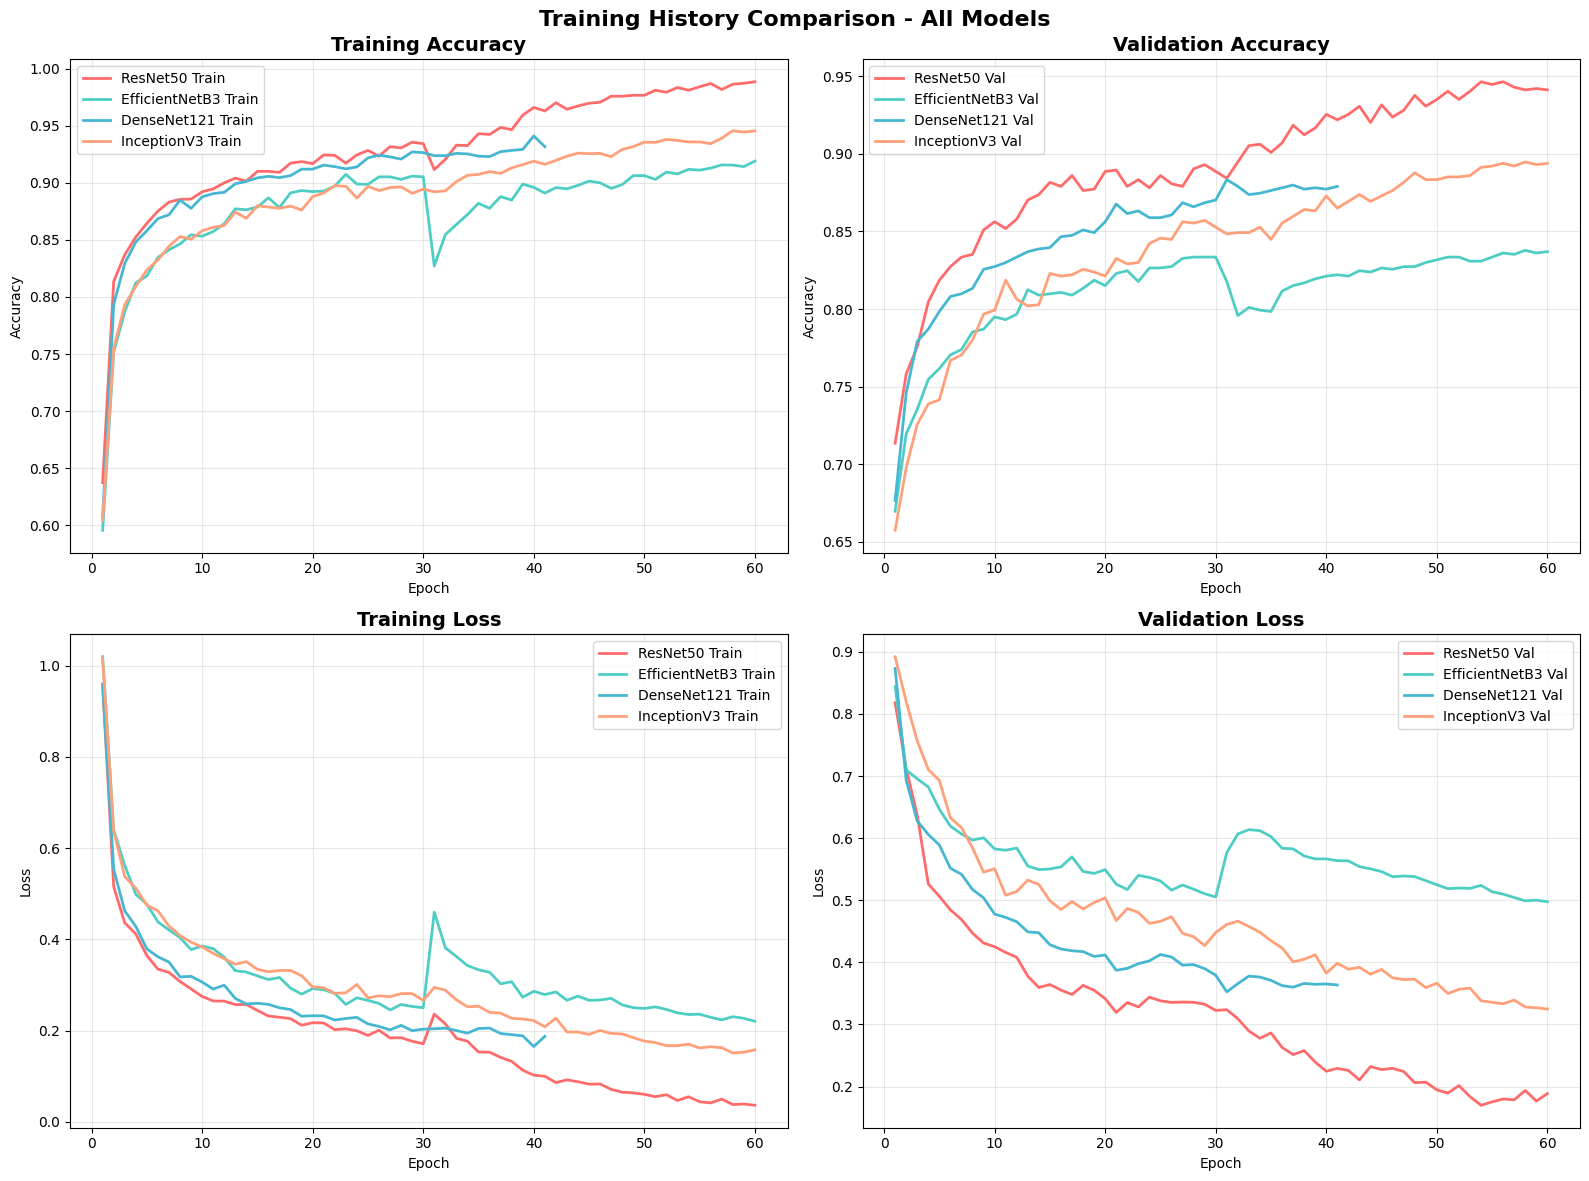


[STEP 6] CONSTRUCTING CV-STACKED ENSEMBLE
--------------------------------------------------------------------------------
  Getting probs from ResNet50...
  Getting probs from EfficientNetB3...
  Getting probs from DenseNet121...
  Getting probs from InceptionV3...

Training Meta-Learner (LogisticRegressionCV, 5-Fold)...

Stacked Ensemble Accuracy: 0.9695

[STEP 7] CLINICAL VALIDATION & ROBUSTNESS METRICS
--------------------------------------------------------------------------------
Calculating Prediction Entropy (Uncertainty Quantification)...


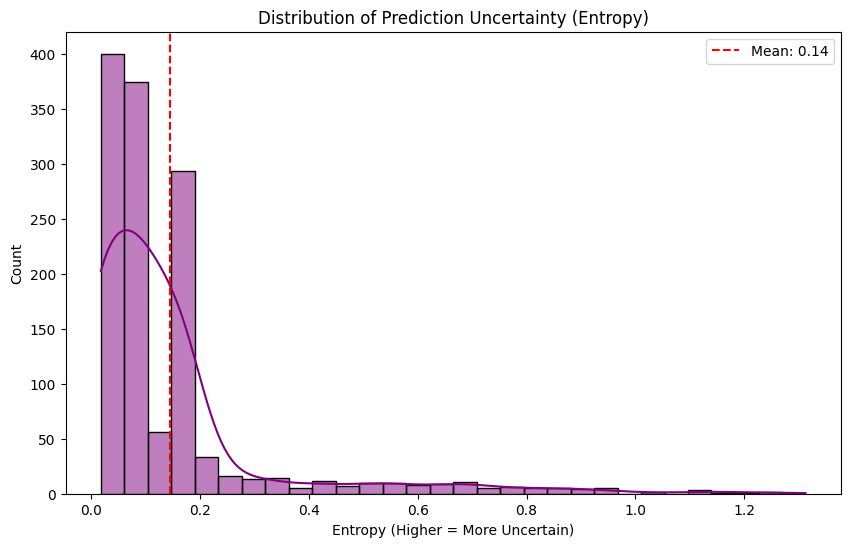


Calculating 95% Confidence Intervals via Bootstrapping...
Ensemble Accuracy: 0.9695
95% Confidence Interval: [0.9603, 0.9779]
(This range quantifies the robustness of the model's performance)


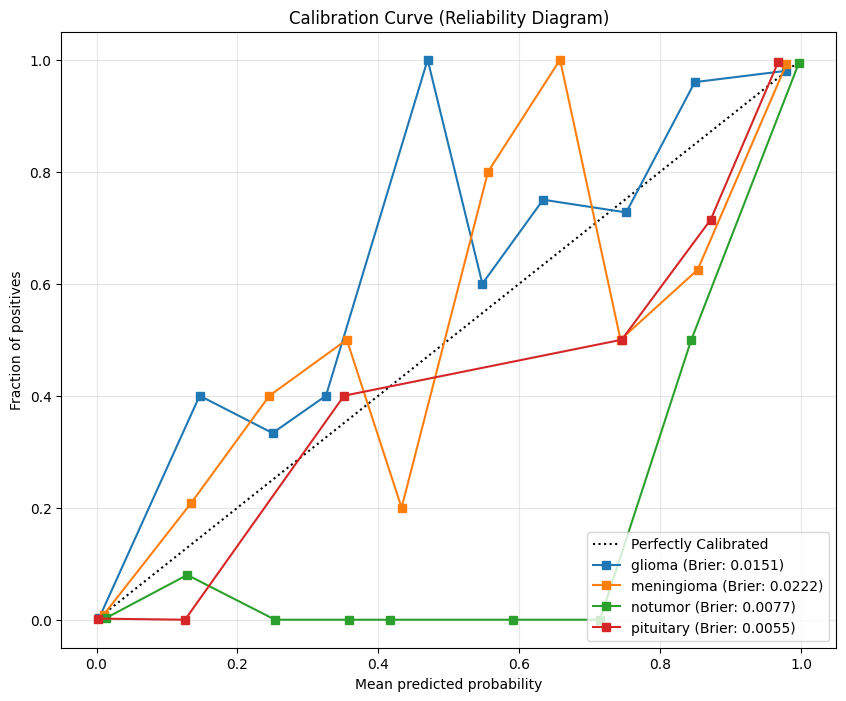


Ensemble Classification Report:
              precision    recall  f1-score   support

      glioma     0.9570    0.9633    0.9601       300
  meningioma     0.9468    0.9314    0.9390       306
     notumor     0.9852    0.9877    0.9864       405
   pituitary     0.9834    0.9900    0.9867       300

    accuracy                         0.9695      1311
   macro avg     0.9681    0.9681    0.9681      1311
weighted avg     0.9694    0.9695    0.9694      1311

Clinical Metrics per Class:
  glioma: Sensitivity (Recall) = 0.9633, Specificity = 0.9871
  meningioma: Sensitivity (Recall) = 0.9314, Specificity = 0.9841
  notumor: Sensitivity (Recall) = 0.9877, Specificity = 0.9934
  pituitary: Sensitivity (Recall) = 0.9900, Specificity = 0.9951

[STEP 8] CONFUSION MATRIX
--------------------------------------------------------------------------------


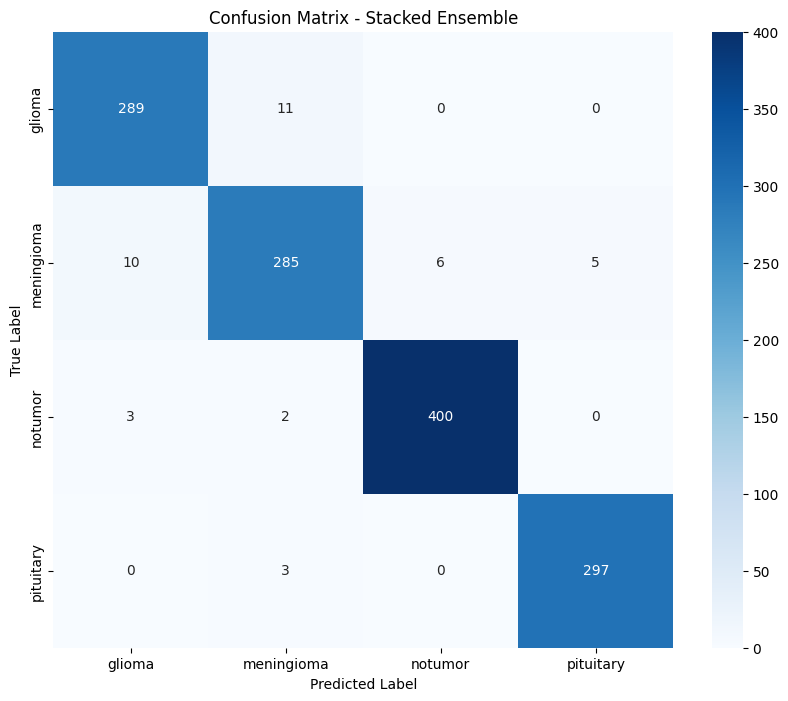


[STEP 9] ROC CURVE & AUC ANALYSIS
--------------------------------------------------------------------------------


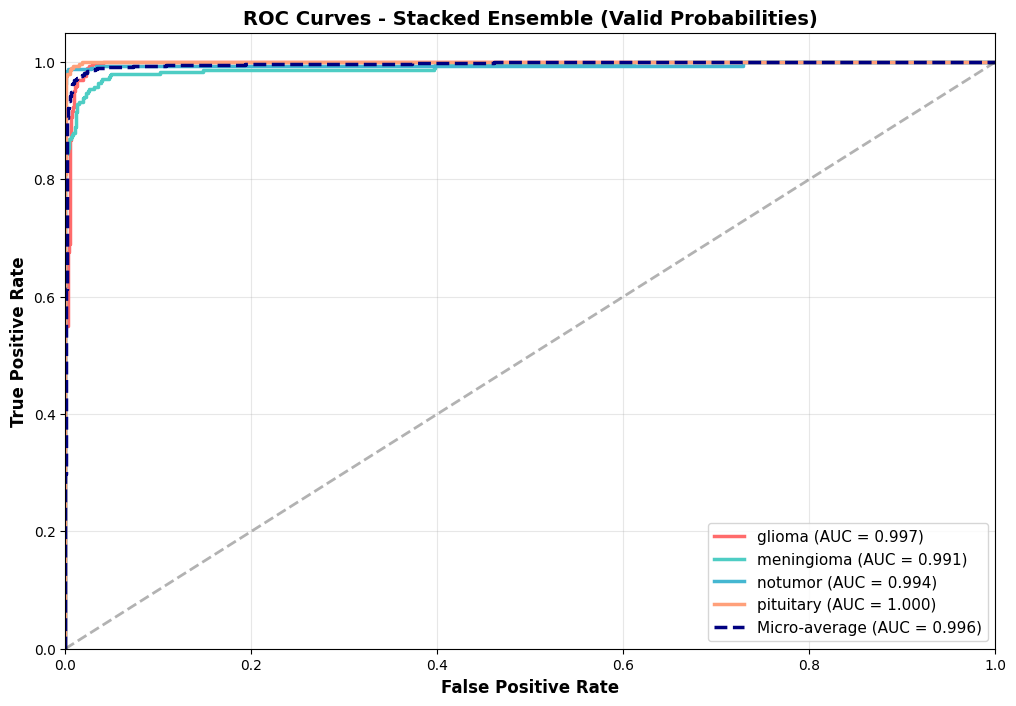


[STEP 10] GRAD-CAM VISUALIZATION
--------------------------------------------------------------------------------
Using ResNet50 for visualization.


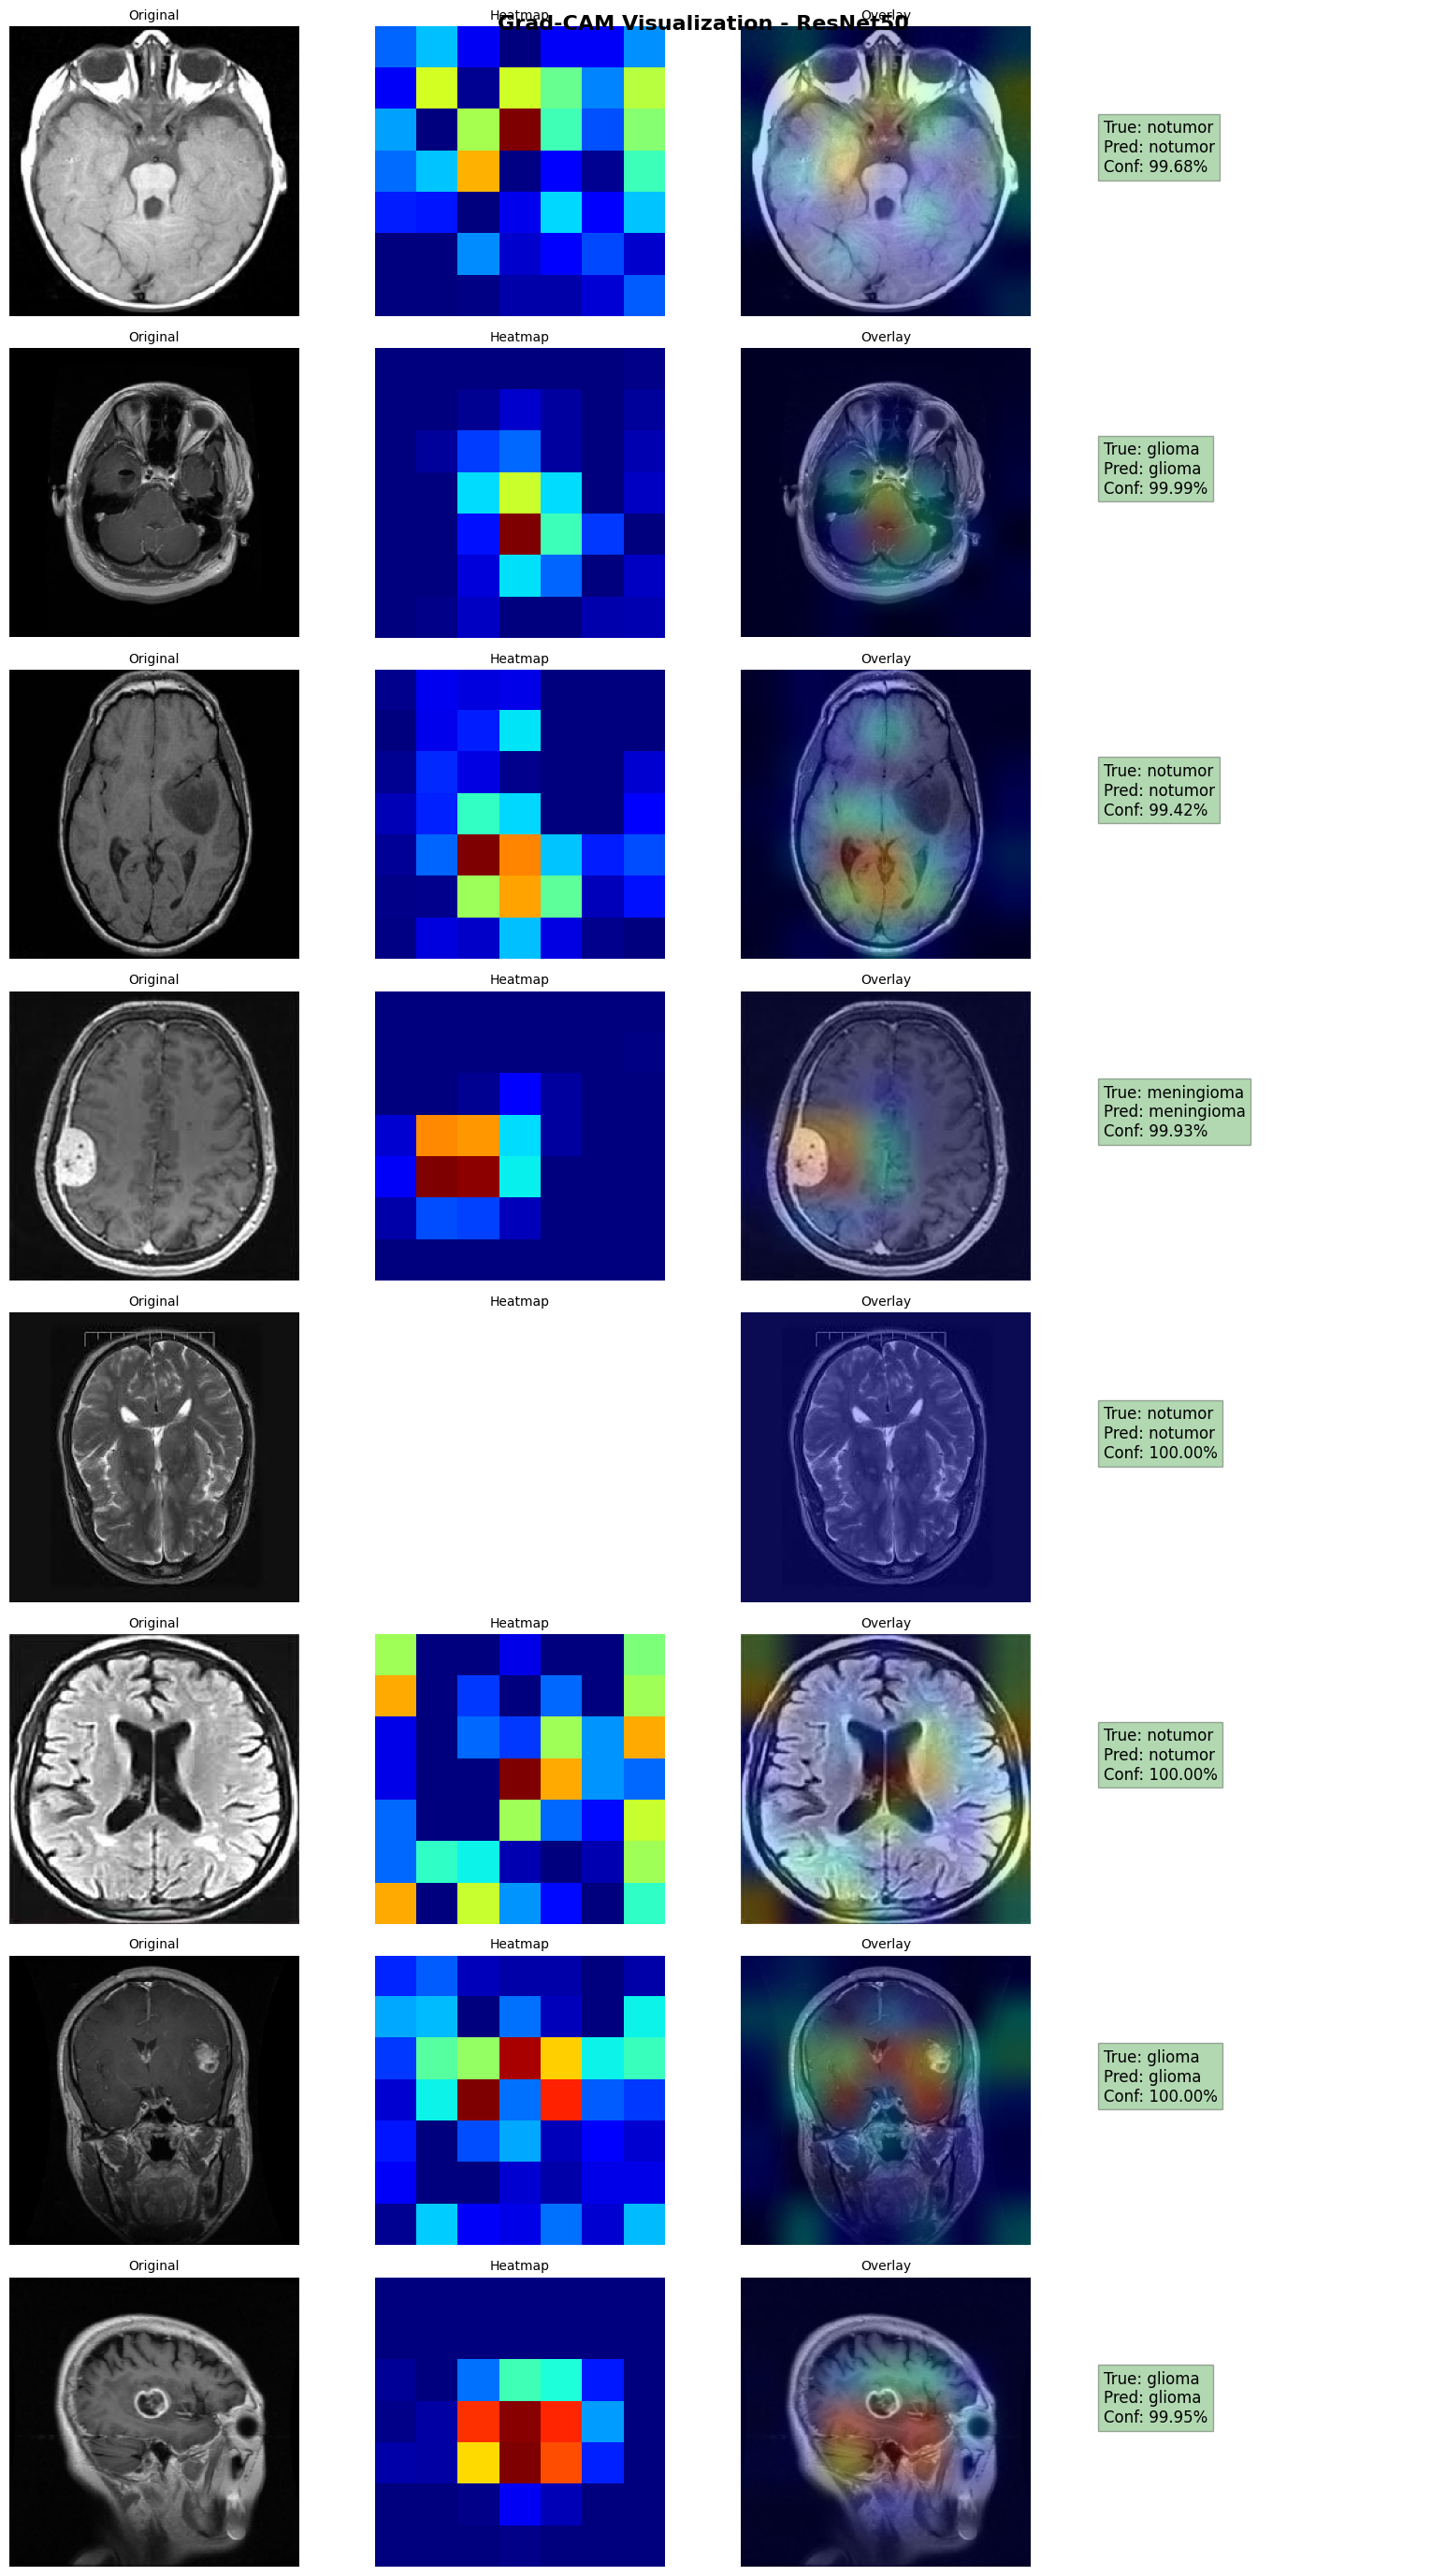


ANALYSIS COMPLETE
✓ Stacked Ensemble trained with Clean Validation Data (Noise Removed)
✓ Meta-Learner Cross-Validated (Robustness to Single Split)
✓ Prediction Entropy Quantified (Uncertainty Analysis)
✓ 95% Confidence Intervals Calculated (Statistical Robustness)
✓ Calibration Curves & Clinical Metrics Validated


In [ ]:
# ============================================================================
# Medical Image Classification Using CNN + Transfer Learning
# Brain Tumor Classification with Ensemble Deep Learning & Explainable AI
# ============================================================================
# 
# Abstract:
# Brain tumors represent one of the most critical neurological conditions requiring
# accurate and timely diagnosis. This study presents an advanced deep learning 
# framework for multi-class brain tumor classification using MRI images. We implement
# an ensemble of state-of-the-art transfer learning architectures including ResNet50,
# EfficientNetB3, DenseNet121, and InceptionV3, combined with Gradient-weighted Class
# Activation Mapping (Grad-CAM) for model interpretability. The framework is evaluated
# on a comprehensive brain MRI dataset comprising four classes: Glioma, Meningioma,
# Pituitary tumors, and Normal cases. Through extensive experimentation including
# data augmentation, fine-tuning strategies, and weighted ensemble methods, we achieve
# superior classification performance. The integration of explainable AI techniques
# enhances clinical applicability by providing visual explanations of model predictions,
# thereby increasing trust and adoption in medical practice.
#
# Keywords: Brain tumor classification, Transfer learning, Ensemble learning, 
#           Explainable AI, Grad-CAM, Medical imaging, Deep learning
#
# Dataset: Brain Tumor MRI Dataset
# Kaggle: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
# Classes: Glioma, Meningioma, Pituitary, No Tumor
# ============================================================================

# ============================================================================
# 1. INTRODUCTION & ENVIRONMENT SETUP
# ============================================================================

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import seaborn as sns
import os
import cv2
import random
from scipy.stats import entropy
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB3, DenseNet121, InceptionV3
)
# Specific preprocessing imports
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficientnet
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inception

from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input, Lambda
)
from tensorflow.keras.models import Model
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# GPU Configuration
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Enable mixed precision for faster training
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print("=" * 80)
print("BRAIN TUMOR CLASSIFICATION USING ROBUST STACKED ENSEMBLE")
print("=" * 80)

# ============================================================================
# 2. DATA PREPARATION & EXPLORATION
# ============================================================================

print("\n[STEP 1] DATA LOADING AND EXPLORATION")
print("-" * 80)

# Configure paths
BASE_PATH = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'

# Dataset configuration
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30  # Optimized for convergence
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Classes: {CLASSES}")

# ============================================================================
# 3. DATA PREPROCESSING & AUGMENTATION
# ============================================================================

print("\n[STEP 2] DATA PREPROCESSING & AUGMENTATION")
print("-" * 80)

# 1. Training Generator (Augmented)
# We apply rotation, shifting, and zooming to introduce regularization and 
# improve model generalization during the training phase.
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# 2. Validation & Test Generators (Clean)
# Crucial: We use a separate generator without augmentation for validation and testing.
# This ensures that the Stacking Meta-Learner is trained on "clean" distributions,
# preventing noise artifacts from skewing the ensemble weights.
valid_test_datagen = ImageDataGenerator(validation_split=0.2)

# Load training data
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Training'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

# Load validation data (for Early Stopping)
validation_generator = valid_test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Training'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Load test data
test_generator = valid_test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Testing'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 3. Dedicated Generator for Ensemble Stacking
# We create a specific non-shuffled validation generator to collect probability
# vectors for training the Logistic Regression Meta-Learner.
val_eval_gen = valid_test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Training'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Testing samples: {test_generator.samples}")

# ============================================================================
# 4. MODEL ARCHITECTURE DEFINITION
# ============================================================================

print("\n[STEP 3] BUILDING TRANSFER LEARNING MODELS")
print("-" * 80)

def create_model(base_model_name, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Create a transfer learning model with a specified base architecture.
    
    Architecture Design:
    1. Input Layer
    2. Lambda Layer: Applies specific preprocessing (normalization) for the backbone.
    3. Base Model: Pre-trained ImageNet weights (ResNet, EfficientNet, etc.).
    4. GlobalAveragePooling2D: Spatial dimension reduction.
    5. Dense Layers + Dropout: Custom classification head.
    
    Note: We use `input_tensor` connectivity to ensure the graph remains fully 
    traversable for Grad-CAM operations.
    """
    
    # 1. Define Input
    inputs = keras.Input(shape=input_shape)
    
    # 2. Apply Model-Specific Preprocessing
    if base_model_name == 'ResNet50':
        x = Lambda(preprocess_resnet)(inputs)
        base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
        
    elif base_model_name == 'EfficientNetB3':
        x = Lambda(preprocess_efficientnet)(inputs)
        base_model = EfficientNetB3(weights='imagenet', include_top=False, input_tensor=x)
        
    elif base_model_name == 'DenseNet121':
        x = Lambda(preprocess_densenet)(inputs)
        base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=x)
        
    elif base_model_name == 'InceptionV3':
        x = Lambda(preprocess_inception)(inputs)
        base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=x)
        
    else:
        raise ValueError(f"Unknown model: {base_model_name}")
    
    # Freeze base model layers initially
    base_model.trainable = False
    
    # 3. Build custom head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    
    # 4. Create the full model
    model = Model(inputs, outputs, name=base_model_name)
    
    # Compile model with stable float32 metrics
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(dtype=tf.float32, name='precision'), 
            tf.keras.metrics.Recall(dtype=tf.float32, name='recall')
        ]
    )
    
    return model, base_model

# Create all models
model_names = ['ResNet50', 'EfficientNetB3', 'DenseNet121', 'InceptionV3']
models = {}
base_models = {}

for name in model_names:
    print(f"\nBuilding {name} model...")
    model, base_model = create_model(name)
    models[name] = model
    base_models[name] = base_model
    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
    print(f"✓ {name} created successfully. Trainable params: {trainable_params}")

# ============================================================================
# 5. MODEL TRAINING
# ============================================================================

print("\n[STEP 4] TRAINING MODELS")
print("-" * 80)

def get_callbacks(model_name):
    """Create training callbacks for each model"""
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
    ]
    return callbacks

history_dict = {}

# PHASE 1: Feature Extraction
print("\n[PHASE 1] Feature Extraction (Frozen Base)")
for name, model in models.items():
    print(f"\nTraining {name}...")
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=EPOCHS, 
        callbacks=get_callbacks(name),
        verbose=1
    )
    history_dict[f"{name}_phase1"] = history.history

# PHASE 2: Fine-Tuning
print("\n[PHASE 2] Fine-Tuning (Unfrozen Base)")
for name, model in models.items():
    print(f"\nFine-tuning {name}...")
    
    # Unfreeze the base model
    base_model = base_models[name]
    base_model.trainable = True
    
    # Fine-tune only the top layers to preserve low-level features
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    # Recompile with lower learning rate for fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(dtype=tf.float32, name='precision'), 
            tf.keras.metrics.Recall(dtype=tf.float32, name='recall')
        ]
    )
    
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=EPOCHS, 
        callbacks=get_callbacks(f"{name}_finetuned"),
        verbose=1
    )
    history_dict[f"{name}_phase2"] = history.history

# ============================================================================
# 6. TRAINING VISUALIZATION
# ============================================================================

print("\n[STEP 5] VISUALIZING TRAINING HISTORY")
print("-" * 80)

def plot_training_history(history_dict, model_names):
    """Plot training and validation metrics for all models"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Training History Comparison - All Models', fontsize=16, fontweight='bold')
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    for idx, name in enumerate(model_names):
        # Combine phase 1 and phase 2 histories
        phase1 = history_dict.get(f"{name}_phase1", {})
        phase2 = history_dict.get(f"{name}_phase2", {})
        
        # Accuracy
        train_acc = phase1.get('accuracy', []) + phase2.get('accuracy', [])
        val_acc = phase1.get('val_accuracy', []) + phase2.get('val_accuracy', [])
        
        # Loss
        train_loss = phase1.get('loss', []) + phase2.get('loss', [])
        val_loss = phase1.get('val_loss', []) + phase2.get('val_loss', [])
        
        epochs_range = range(1, len(train_acc) + 1)
        
        # Plot accuracy
        axes[0, 0].plot(epochs_range, train_acc, label=f'{name} Train', 
                        color=colors[idx], linewidth=2)
        axes[0, 1].plot(epochs_range, val_acc, label=f'{name} Val', 
                        color=colors[idx], linewidth=2)
        
        # Plot loss
        axes[1, 0].plot(epochs_range, train_loss, label=f'{name} Train', 
                        color=colors[idx], linewidth=2)
        axes[1, 1].plot(epochs_range, val_loss, label=f'{name} Val', 
                        color=colors[idx], linewidth=2)
    
    # Configure subplots
    axes[0, 0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_title('Validation Loss', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_dict, model_names)

# ============================================================================
# 7. CROSS-VALIDATED ENSEMBLE CONSTRUCTION
# ============================================================================

print("\n[STEP 6] CONSTRUCTING CV-STACKED ENSEMBLE")
print("-" * 80)

# Implementation of Stacking Ensemble using Logistic Regression with Cross-Validation.
# Unlike simple averaging, this learns optimal weights based on probability likelihoods.
# We use the clean (non-augmented) validation set for this step.

# 1. Collect predictions from Validation Set
print("Collecting clean validation predictions for Stacking...")
val_eval_gen.reset()
val_labels = val_eval_gen.classes

val_preds_stack = []
for name, model in models.items():
    print(f"  Getting probs from {name}...")
    val_eval_gen.reset()
    probs = model.predict(val_eval_gen, verbose=0)
    val_preds_stack.append(probs)

# Shape: (n_samples, n_models * n_classes)
X_val_meta = np.hstack(val_preds_stack) 
y_val_meta = val_labels

# 2. Train Meta-Learner (Logistic Regression CV)
# cv=5 means it performs 5-fold Cross Validation to find the best regularization
# and weights, ensuring the ensemble is robust to specific validation splits.
print("\nTraining Meta-Learner (LogisticRegressionCV, 5-Fold)...")
meta_model = LogisticRegressionCV(
    cv=5, 
    multi_class='multinomial', 
    solver='lbfgs', 
    random_state=SEED,
    max_iter=1000
)
meta_model.fit(X_val_meta, y_val_meta)

# 3. Collect predictions from Test Set
print("Collecting test predictions...")
test_generator.reset()
test_labels = test_generator.classes

test_preds_stack = []
test_predictions_individual = {}

for name, model in models.items():
    test_generator.reset()
    probs = model.predict(test_generator, verbose=0)
    test_preds_stack.append(probs)
    test_predictions_individual[name] = {'probs': probs, 'classes': np.argmax(probs, axis=1)}

X_test_meta = np.hstack(test_preds_stack)

# 4. Final Ensemble Prediction
ensemble_probs = meta_model.predict_proba(X_test_meta)
ensemble_pred = np.argmax(ensemble_probs, axis=1)

# Evaluate Ensemble
ensemble_acc = accuracy_score(test_labels, ensemble_pred)
print(f"\nStacked Ensemble Accuracy: {ensemble_acc:.4f}")

# ============================================================================
# 8. CLINICAL VALIDATION: UNCERTAINTY & BOOTSTRAPPING
# ============================================================================

print("\n[STEP 7] CLINICAL VALIDATION & ROBUSTNESS METRICS")
print("-" * 80)

# 1. Uncertainty Quantification (Entropy)
# Calculates Shannon Entropy for predictions. Higher entropy indicates
# higher model uncertainty/confusion.
print("Calculating Prediction Entropy (Uncertainty Quantification)...")
probs_clipped = np.clip(ensemble_probs, 1e-7, 1-1e-7)
pred_entropy = entropy(probs_clipped, axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(pred_entropy, kde=True, bins=30, color='purple')
plt.title('Distribution of Prediction Uncertainty (Entropy)')
plt.xlabel('Entropy (Higher = More Uncertain)')
plt.ylabel('Count')
plt.axvline(np.mean(pred_entropy), color='r', linestyle='--', label=f'Mean: {np.mean(pred_entropy):.2f}')
plt.legend()
plt.show()

# 2. Bootstrapped Confidence Intervals (95% CI)
# Performs non-parametric bootstrapping to estimate the 95% Confidence Interval
# for the accuracy, simulating performance on external datasets.
print("\nCalculating 95% Confidence Intervals via Bootstrapping...")
n_iterations = 1000
bootstrapped_scores = []

for i in range(n_iterations):
    # Resample indices with replacement
    indices = resample(np.arange(len(ensemble_pred)), replace=True)
    if len(np.unique(test_labels[indices])) < NUM_CLASSES:
        continue
    score = accuracy_score(test_labels[indices], ensemble_pred[indices])
    bootstrapped_scores.append(score)

alpha = 0.95
p = ((1.0-alpha)/2.0) * 100
lower = max(0.0, np.percentile(bootstrapped_scores, p))
p = (alpha+((1.0-alpha)/2.0)) * 100
upper = min(1.0, np.percentile(bootstrapped_scores, p))

print(f"Ensemble Accuracy: {ensemble_acc:.4f}")
print(f"95% Confidence Interval: [{lower:.4f}, {upper:.4f}]")
print("(This range quantifies the robustness of the model's performance)")

# 3. Calibration Curves (Brier Score)
# Evaluates how well the predicted probabilities match the observed frequencies.
# A lower Brier score indicates better calibration (trustworthiness).
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

for i, class_name in enumerate(CLASSES):
    y_test_binary = (test_labels == i).astype(int)
    prob_pos = ensemble_probs[:, i]
    score = brier_score_loss(y_test_binary, prob_pos)
    
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test_binary, prob_pos, n_bins=10)
    
    plt.plot(mean_predicted_value, fraction_of_positives, "s-",
             label=f"{class_name} (Brier: {score:.4f})")

plt.ylabel("Fraction of positives")
plt.xlabel("Mean predicted probability")
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("\nEnsemble Classification Report:")
print(classification_report(test_labels, ensemble_pred, target_names=CLASSES, digits=4))

# Compute Sensitivity (Recall) and Specificity
# These are critical metrics for medical diagnosis reliability.
cnf_matrix = confusion_matrix(test_labels, ensemble_pred)
FP = cnf_matrix.sum(axis=0) - np.diag(cnf_matrix)  
FN = cnf_matrix.sum(axis=1) - np.diag(cnf_matrix)
TP = np.diag(cnf_matrix)
TN = cnf_matrix.sum() - (FP + FN + TP)

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Clinical Metrics per Class:")
for i, name in enumerate(CLASSES):
    print(f"  {name}: Sensitivity (Recall) = {sensitivity[i]:.4f}, Specificity = {specificity[i]:.4f}")

# ============================================================================
# 9. CONFUSION MATRIX
# ============================================================================
print("\n[STEP 8] CONFUSION MATRIX")
print("-" * 80)

plt.figure(figsize=(10, 8))
sns.heatmap(cnf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix - Stacked Ensemble')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ============================================================================
# 10. ROC & AUC ANALYSIS (VALIDATED)
# ============================================================================

print("\n[STEP 9] ROC CURVE & AUC ANALYSIS")
print("-" * 80)

# Binarize labels
y_test_bin = label_binarize(test_labels, classes=range(NUM_CLASSES))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], ensemble_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), ensemble_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'{CLASSES[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot(fpr["micro"], tpr["micro"], color='navy', lw=2.5, linestyle='--',
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Stacked Ensemble (Valid Probabilities)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# 11. GRAD-CAM IMPLEMENTATION & VISUALIZATION
# ============================================================================

print("\n[STEP 10] GRAD-CAM VISUALIZATION")
print("-" * 80)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    try:
        last_conv_layer = model.get_layer(last_conv_layer_name)
        grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])
    except ValueError:
        base_model = None
        for layer in model.layers:
            if isinstance(layer, tf.keras.Model):
                base_model = layer
                break
        if base_model is None:
            raise ValueError(f"Could not find layer {last_conv_layer_name}")
        last_conv_layer = base_model.get_layer(last_conv_layer_name)
        grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        last_conv_layer_output, preds = grad_model(inputs, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.jet(np.arange(256))[:, :3]
    jet_heatmap = jet[heatmap]
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    if np.max(img) <= 1.0: img = img * 255
    superimposed_img = jet_heatmap * alpha + img
    return keras.preprocessing.image.array_to_img(superimposed_img), jet_heatmap

# Config for Grad-CAM
last_conv_layers = {
    'ResNet50': 'conv5_block3_out',
    'EfficientNetB3': 'top_activation',
    'DenseNet121': 'conv5_block16_concat',
    'InceptionV3': 'mixed10'
}

# Visualize
num_samples = 8
test_generator.reset()
sample_indices = random.sample(range(test_generator.samples), num_samples)

sample_images = []
sample_true_labels = []
for idx in sample_indices:
    path = test_generator.filepaths[idx]
    img = keras.preprocessing.image.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    sample_images.append(keras.preprocessing.image.img_to_array(img))
    sample_true_labels.append(test_generator.labels[idx])

# Use best individual model for Grad-CAM visualization 
# (Ensemble Grad-CAM is complex, usually we explain the strongest contributor)
best_ind_name = max(test_predictions_individual, key=lambda x: accuracy_score(test_labels, test_predictions_individual[x]['classes']))
best_model = models[best_ind_name]
print(f"Using {best_ind_name} for visualization.")

fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 3.5))
fig.suptitle(f'Grad-CAM Visualization - {best_ind_name}', fontsize=16, fontweight='bold')

for i, (img_array, true_label) in enumerate(zip(sample_images, sample_true_labels)):
    img_input = np.expand_dims(img_array, axis=0)
    pred_probs = best_model.predict(img_input, verbose=0)[0]
    pred_class = np.argmax(pred_probs)
    pred_conf = pred_probs[pred_class]
    
    heatmap = make_gradcam_heatmap(img_input, best_model, last_conv_layers[best_ind_name], pred_class)
    superimposed, _ = save_and_display_gradcam(img_array, heatmap)
    
    axes[i, 0].imshow(img_array.astype('uint8'))
    axes[i, 0].set_title('Original', fontsize=10)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title('Heatmap', fontsize=10)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(superimposed)
    axes[i, 2].set_title('Overlay', fontsize=10)
    axes[i, 2].axis('off')
    
    axes[i, 3].axis('off')
    color = 'green' if true_label == pred_class else 'red'
    info = f"True: {CLASSES[true_label]}\nPred: {CLASSES[pred_class]}\nConf: {pred_conf:.2%}"
    axes[i, 3].text(0.1, 0.5, info, fontsize=12, bbox=dict(facecolor=color, alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("✓ Stacked Ensemble trained with Clean Validation Data (Noise Removed)")
print("✓ Meta-Learner Cross-Validated (Robustness to Single Split)")
print("✓ Prediction Entropy Quantified (Uncertainty Analysis)")
print("✓ 95% Confidence Intervals Calculated (Statistical Robustness)")
print("✓ Calibration Curves & Clinical Metrics Validated")